In [42]:
import numpy as np
import pandas as pd
from pathlib import Path
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
DATA_PROCESSED = ROOT / "data" / "processed"

signals = pd.read_csv(DATA_PROCESSED / "signals.csv", 
                      index_col=0, parse_dates=True)

In [43]:
# HMM learns from slope, vrp and realised volatility
features = signals[["vrp", "slope", "rv_30"]].dropna()

print("Feature matrix shape:", X.shape)
print("\nMeans (should be ~0 after scaling):", X.mean(axis=0).round(4))
print("Stds  (should be ~1 after scaling):", X.std(axis=0).round(4))

Feature matrix shape: (4964, 3)

Means (should be ~0 after scaling): [ 0. -0. -0.]
Stds  (should be ~1 after scaling): [1. 1. 1.]


In [44]:
# Split date
SPLIT = "2016-01-01"

# Training data only: HMM never sees post-2015
train = features[features.index < SPLIT]
test  = features[features.index >= SPLIT]

X_train = scaler.fit_transform(train[["vrp", "slope", "rv_30"]])
X_test  = scaler.transform(test[["vrp", "slope", "rv_30"]])

print(f"Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} days)")
print(f"Test:  {test.index[0].date()}  → {test.index[-1].date()}  ({len(test)} days)")

# Fit on train only
model = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)
model.fit(X_train)
print(f"\nConverged: {model.monitor_.converged}")

Train: 2006-08-29 → 2015-12-31 (2352 days)
Test:  2016-01-04  → 2026-05-22  (2612 days)

Converged: True


In [45]:
# Predict regimes on BOTH periods separately
train_states = model.predict(X_train)
test_states  = model.predict(X_test)

# Combine back into one series
train_copy = train.copy()
test_copy  = test.copy()
train_copy["regime"] = train_states
test_copy["regime"]  = test_states

features_all = pd.concat([train_copy, test_copy]).sort_index()

# Identify state labels from TRAINING data only
print("State characteristics (from training data):\n")
for s in range(3):
    mask = train_copy["regime"] == s
    print(f"State {s} ({mask.mean()*100:.1f}% of train days)")
    print(f"  VRP mean:   {train_copy.loc[mask, 'vrp'].mean():.4f}")
    print(f"  Slope mean: {train_copy.loc[mask, 'slope'].mean():.4f}")
    print(f"  RV mean:    {train_copy.loc[mask, 'rv_30'].mean():.4f}")
    print()

State characteristics (from training data):

State 0 (25.5% of train days)
  VRP mean:   0.0362
  Slope mean: 0.0587
  RV mean:    0.1999

State 1 (13.9% of train days)
  VRP mean:   -0.0049
  Slope mean: -0.0130
  RV mean:    0.4091

State 2 (60.6% of train days)
  VRP mean:   0.0386
  Slope mean: 0.1196
  RV mean:    0.1143



In [46]:
state_map = {2: "calm", 0: "stressed", 1: "crisis"}

features_all["regime_label"] = features_all["regime"].map(state_map)

signals = signals.join(features_all[["regime", "regime_label"]])
signals.to_csv(DATA_PROCESSED / "regimes.csv")
print("Saved regimes.csv")
print(signals["regime_label"].value_counts())

Saved regimes.csv
regime_label
calm        3066
stressed    1353
crisis       545
Name: count, dtype: int64


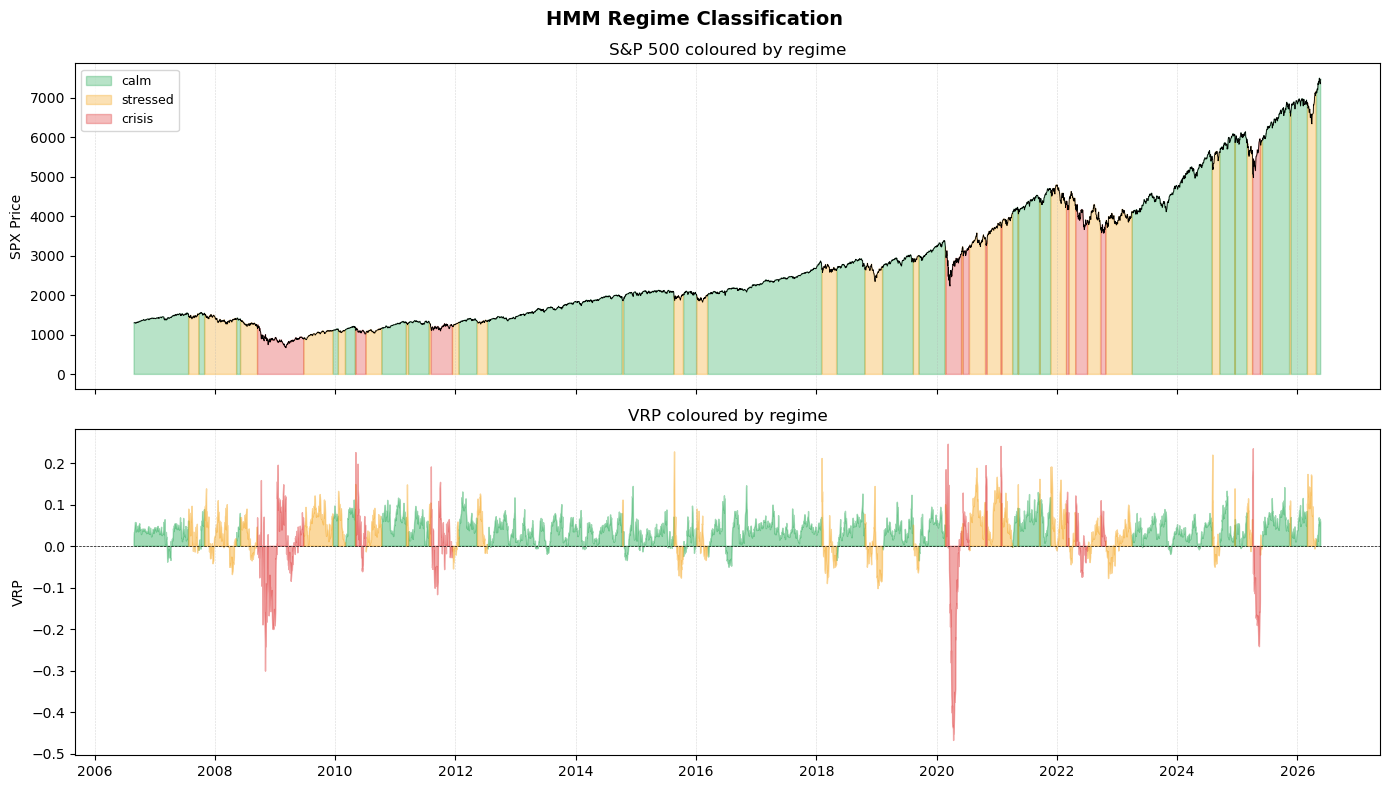

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("HMM Regime Classification", fontsize=14, fontweight="bold")

# Colour map for regimes
colors = {"calm": "#16a34a", "stressed": "#f59e0b", "crisis": "#dc2626"}

# Panel 1: SPX coloured by regime
for label, color in colors.items():
    mask = signals["regime_label"] == label
    axes[0].fill_between(signals.index, signals["spx"],
                         where=mask, color=color, alpha=0.3, label=label)
axes[0].plot(signals.index, signals["spx"], color="black", linewidth=0.6)
axes[0].set_ylabel("SPX Price")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].set_title("S&P 500 coloured by regime")

# Panel 2: VRP coloured by regime
for label, color in colors.items():
    mask = signals["regime_label"] == label
    axes[1].fill_between(signals.index, signals["vrp"],
                         where=mask, color=color, alpha=0.4)
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("VRP")
axes[1].set_title("VRP coloured by regime")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "regimes_overview.png", dpi=150, bbox_inches="tight")
plt.show()